# SARSA: State-Action-Reward-State-Action

En este ejercicio vamos a implementar el algoritmo de SARSA como un ejemplo de los métodos on-policy para el aprendizaje por refuerzo. Esto es, crear agentes que aprenden a alcanzar un objetivo específico.

El método de SARSA se basa en el cálculo de los q-valores utilizando los valores calculados para el estado de llegada siguiendo la fórmula de actualización de los q-valores:

$Q(s,a) \leftarrow (1-\alpha)Q(s,a) + \alpha[R(s) + \gamma Q(s',a')] $

Para implementar SARSA definiremos un agente, `sarsa_agent.py` el cual utilizaremos para interactuar con el ambiente de Gridworld.

#### Task 1
1.	Implemente la clase `SARSA` con cinco atributos:
    - `epsilon` que corresponde a la estrategia de aprendizaje $\epsilon$-greedy, `0.9` por defecto.
    - `gamma` que corresponde al factor de decuento a utilizar, `0.96` por defecto.
    - `alpha` que corresponde a la taza de aprendizajem `0.81` por defecto.
    - `Q` que almacena los q-valores del agente.
    - `env` que es una referencia al ambiente.

2. El comportamiento del agente (la interacción con el ambiente) esta dado por los métodos:
    - `choose_action` que recibe un estado como parámetro y retorna la acción a ejecutar para dicho estado siguiendo una estrategia $\epsilon$-greedy.
    - `action_function` que recibe como parámetro los componentes de SARSA (estado1, acción1, recompensa, estado2, acción2) y calcula el q-valor `Q(estdo1, acción1)`.

3. La interacción entre el agente y el ambiente inicia desde el ambiente, que ejecuta cada interacción de SARSA para cada episodio.
(1) La interacción comienza decidiendo la acción a tomar para el estado actual (la cual esta dada por el agente), (2) luego debemos ejecutar la acción, obteniendo el estado de llegada y la recompensa de ejecutar dicha acción, (3) luego calculamos la acción a tomar para el estado de llegada, (4) por último calculamos el q-valor definido por la función de las acciones.

#### Task 2
Implemente el ambiente de cliff-walk (basado en el ambiente de Gridworld utilizdo anteriormente) y resulevalo utilizando el método de SARSA.
Recuerde que en este ambiente la recompensa por caer al barranco es de -100 y la recompensa de cada paso es -1.
Para la ejecución vamos a suponer acciones determinísticas.

![cliff-walk](cliff-walk.png)

Además responda las siguientes preguntas
1. ¿Cuál es el comportamiento del agente si utilizamos un factor de descuento de 1?
2. ¿Cómo podemos minimizar la trayectoria del agente entre el estado inicial y el estado de llegada?

Justifique sus respuestas con ejecuciones reales del agente.

# Solución

In [68]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, ".")

from environment import Environment
from sarsa_agent import SARSA

np.random.seed(7)

In [28]:
def plot(agent, title):
    env = agent.env
    policy = agent.greedy_policy()

    all_q_vals = [v for sq in agent.Q.values() for v in sq.values()]
    q_min = min(all_q_vals) if all_q_vals else 0.0
    q_max = max(all_q_vals) if all_q_vals else 1.0
    if q_max == q_min:
        q_max = q_min + 1.0

    cmap = plt.get_cmap("RdYlGn")

    def q_color(val):
        return cmap((val - q_min) / (q_max - q_min))

    cell_size = 1.5 if max(env.nrows, env.ncols) <= 6 else 1.1
    q_font = 7 if max(env.nrows, env.ncols) <= 6 else 5
    center_font = 10 if max(env.nrows, env.ncols) <= 6 else 7

    fig, ax = plt.subplots(figsize=(env.ncols * cell_size, env.nrows * cell_size))
    ax.set_xlim(-0.5, env.ncols - 0.5)
    ax.set_ylim(env.nrows - 0.5, -0.5)
    ax.set_aspect("equal")

    action_symbol = {"up": "↑", "down": "↓", "left": "←", "right": "→", "exit": "◉"}

    def triangle_verts(cx, cy, action):
        return {
            "up":    [(cx-0.5, cy-0.5), (cx+0.5, cy-0.5), (cx, cy)],
            "down":  [(cx-0.5, cy+0.5), (cx+0.5, cy+0.5), (cx, cy)],
            "left":  [(cx-0.5, cy-0.5), (cx-0.5, cy+0.5), (cx, cy)],
            "right": [(cx+0.5, cy-0.5), (cx+0.5, cy+0.5), (cx, cy)],
        }[action]

    def label_pos(cx, cy, action):
        return {
            "up":    (cx,       cy-0.28),
            "down":  (cx,       cy+0.28),
            "left":  (cx-0.28,  cy),
            "right": (cx+0.28,  cy),
        }[action]

    for i in range(env.nrows):
        for j in range(env.ncols):
            cell = env.board[i][j]
            cx, cy = j, i

            if cell == env.PROHIBITED_CELL:
                ax.add_patch(plt.Rectangle((cx-0.5, cy-0.5), 1, 1, color="black", zorder=2))
                continue

            state = (i, j)
            agent._ensure_state(state)
            state_q = agent.Q[state]

            if "exit" in state_q:
                exit_val = state_q["exit"]
                ax.add_patch(plt.Rectangle((cx-0.5, cy-0.5), 1, 1, color=q_color(exit_val), zorder=2))
                ax.text(cx, cy, f"{action_symbol.get("exit", "")}\n{exit_val:.1f}", ha="center", va="center",
                        fontsize=q_font + 1, fontweight="bold", zorder=3)
            else:
                for action in ["up", "down", "left", "right"]:
                    q_val = state_q.get(action, 0.0)
                    xs, ys = zip(*triangle_verts(cx, cy, action))
                    ax.fill(xs, ys, color=q_color(q_val), zorder=2)
                    lx, ly = label_pos(cx, cy, action)
                    ax.text(lx, ly, f"{q_val:.2f}", ha="center", va="center",
                            fontsize=q_font, zorder=3)

                ax.add_patch(plt.Rectangle((cx-0.5, cy-0.5), 1, 1, fill=False,
                                           edgecolor="gray", linewidth=0.5, zorder=4))

                best = policy.get(state, "")
                ax.text(cx, cy, action_symbol.get(best, ""), ha="center", va="center",
                        fontsize=center_font, fontweight="bold", color="black", zorder=5)

                if cell == env.INITIAL_CELL:
                    ax.text(cx-0.38, cy-0.38, "S", fontsize=q_font,
                            color="navy", fontweight="bold", zorder=6)

    ax.set_xticks(np.arange(-0.5, env.ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.nrows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=q_min, vmax=q_max))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.8, label="Q(s,a)")

    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

Gridworld: 3x4, estado inicial: (2, 0)


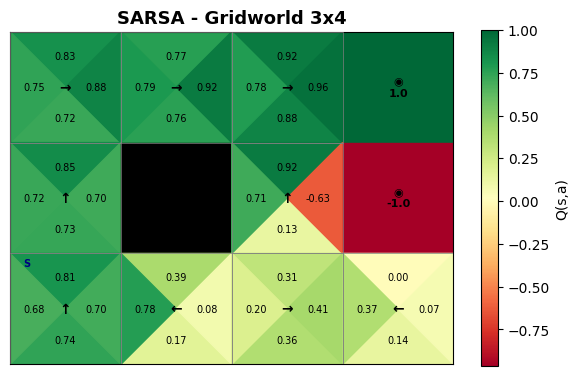

In [30]:
grid_board = [
    [" ", " ", " ", "+1"],
    [" ", "#", " ", "-1"],
    ["S", " ", " ", " "],
]

env_small = Environment(grid_board)
print(f"Gridworld: {env_small.nrows}x{env_small.ncols}, estado inicial: {env_small.initial_state}")

agent = SARSA(env_small)
agent.train(
    episodes=1_000,
    max_steps=1_000,
    epsilon_decay=0.9,
    min_epsilon=0.05,
    step_reward=0,
)

plot(agent, "SARSA - Gridworld 3x4")


Gridworld: 10x10, estado inicial: (0, 0)


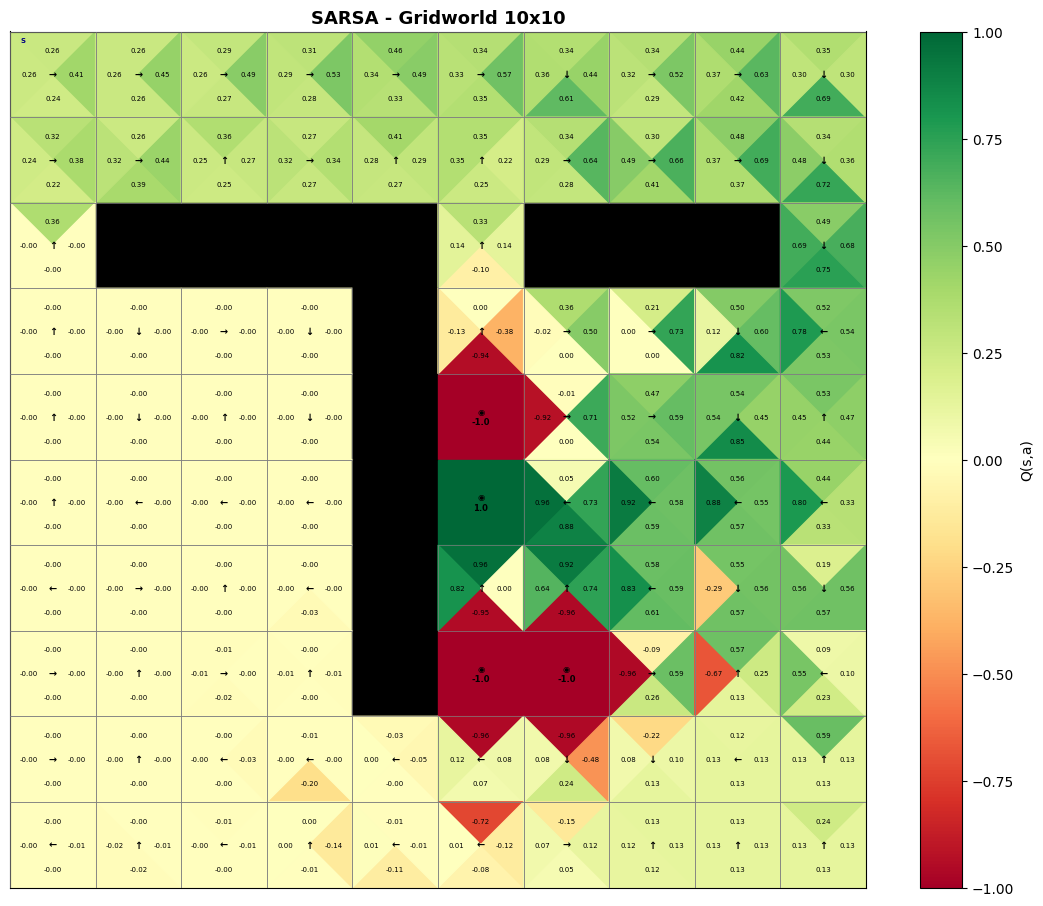

In [32]:
grid_board_big = [
    ["S", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", "#", "#", "#", "#", " ", "#", "#", "#", " "],
    [" ", " ", " ", " ", "#", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", "-1", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", "1", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", "#", "-1", "-1", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
]

env_big = Environment(grid_board_big)
print(f"Gridworld: {env_big.nrows}x{env_big.ncols}, estado inicial: {env_big.initial_state}")


agent = SARSA(env_big)
agent.train(
    episodes=5_000,
    max_steps=1_000,
    epsilon_decay=0.9,
    min_epsilon=0.05,
    step_reward=0,
)

plot(agent, "SARSA - Gridworld 10x10")


Gridworld: Cliff, estado inicial: (4, 0)


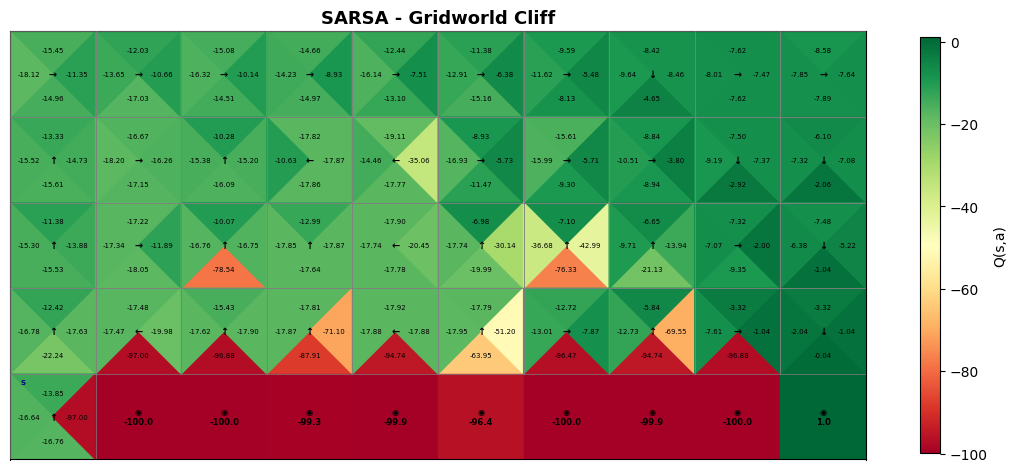

In [34]:
grid_board_cliff = [
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    [" ", " ", " ", " ", " ", " ", " ", " ", " ", " "],
    ["S", "-100", "-100", "-100", "-100", "-100", "-100", "-100", "-100", "1"],
]

env_cliff = Environment(grid_board_cliff)
print(f"Gridworld: Cliff, estado inicial: {env_cliff.initial_state}")


agent = SARSA(env_cliff)
agent.train(
    episodes=5_000,
    max_steps=1_000,
    epsilon_decay=0.9,
    min_epsilon=0.05,
    step_reward=-1,
)

plot(agent, "SARSA - Gridworld Cliff")


## Pregunta 1. Comportamiento del agente con  factor de descuento gamma = 1 en Gridworld Cliff

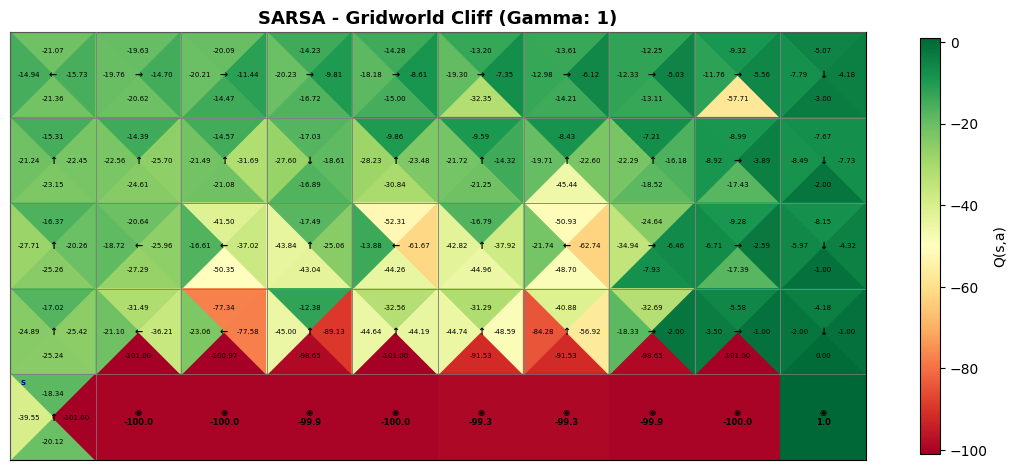

In [35]:
agent = SARSA(env_cliff, gamma=1)
agent.train(
    episodes=5_000,
    max_steps=1_000,
    epsilon_decay=0.9,
    min_epsilon=0.05,
    step_reward=-1,
)

plot(agent, "SARSA - Gridworld Cliff (Gamma: 1)")

En este caso, vemos que el agente aprende a evitar el barranco, aunque en algunas partes, prefiere quedarse permanentemente alejado de él (como en la esquina superior izquierda). No obstante, el agente no aprende a tomar la ruta más corta entre el estado inicial y el estado de llegada, lo que se puede explicar por el hecho de que el agente no tiene un incentivo para tomar la ruta más corta, ya que el factor de descuento es 1, lo que significa que el agente valora las recompensas futuras tanto como las recompensas inmediatas y por ende prefiere mantener la seguridad de la recolección de la recomensa de -1 por cada paso, en lugar de arriesgarse a caer al barranco y obtener una recompensa de -100, así hasta finalizar el episodio llegando al estado de llegada.

## 2. Minimizando la trayectoria del agente entre el estado inicial y el estado de llegada

Para ajustar los hiperparámetros aumentaremos un poco la recompensa por paso, para que el agente tenga un incentivo para tomar la ruta más corta, pero sin que esta sea tan grande como para que el agente prefiera caer al barranco. Aumentaremos a a 0.95 el factor de descuento para propagar la señal de la meta a través de una mayor cantidad de pasos, y ajustaremos el learning rate y la tasa de exploración para estabilizar el aprendizaje y permitir suficiente exploración antes de explotar la política greedy.

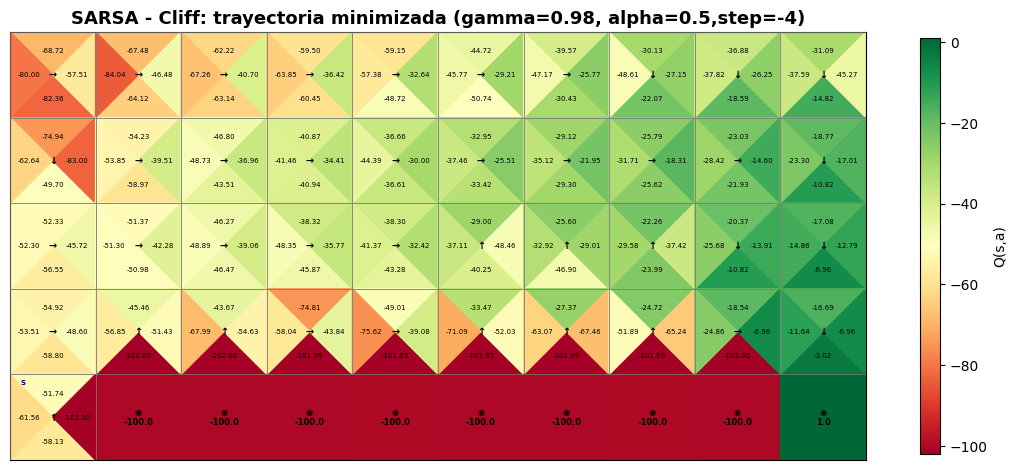

In [107]:
agent = SARSA(env_cliff, gamma=0.98, alpha=0.5)

np.random.seed(7)
returns, steps = agent.train(
    episodes=10_000,
    max_steps=500,
    epsilon_decay=0.998,
    min_epsilon=0.01,
    step_reward=-4,
)

plot(agent, "SARSA - Cliff: trayectoria minimizada (gamma=0.98, alpha=0.5,step=-4)")


Como podemos ver, el agente ya no toma la más lejana del barranco, esto es debido a que estamos manteniendo una tasa de aprendizaje baja, por lo que tanto los errores de caer al barranco no tendrán tanto peso entre la ejecución de los episodios.

También, la buena propagación de las recomensas a través de un factor de descuento alto, hace que el agente tenga un incentivo para tomar la ruta más corta, aunque sin arriesgarse a caer al barranco, lo que se refleja en la política aprendida por el agente.

No obstante, si aumentamos demasiado la recompensa por paso, el agente prefiere caer al barranco, ya que el incentivo de tomar la ruta más corta es tan grande que el agente prefiere arriesgarse a caer al barranco y obtener una recompensa de -100, en lugar de mantener la seguridad de la recolección de la recomensa por paso, lo que se refleja en la política aprendida por el agente.

Finalmente, en nuestro ejercicio, el agente no aprendió a tomar la ruta completamente óptima pero sí hubo una mejoría (está a sólo 2 pasos de la ruta óptima) y el agente aprendió a evitar el barranco.
Asumo que el proceso de tuning sería mejor enfocado en tratar de ajustar las recompensas tanto de caída como de llegada, para balancear el incentivo de tomar la ruta más corta, más que tunear los hiperparámetros de aprendizaje.